<a href="https://www.kaggle.com/code/lalit7881/bitcoin-historical-dataset-for-market-eda?scriptVersionId=325828527" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashrafkhetran/bitcoin-historical-dataset-for-market-analysis/bitcoin_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashrafkhetran/bitcoin-historical-dataset-for-market-analysis/bitcoin_dataset.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4275,2026-06-01,73580.210938,73969.570312,70599.507812,71319.773438,71319.773438,43378836121
4276,2026-06-02,71321.031250,71334.953125,66127.265625,66703.656250,66703.656250,54990073882
4277,2026-06-03,66694.007812,67402.929688,64009.675781,64014.367188,64014.367188,47411556213
4278,2026-06-04,64020.070312,64664.445312,61335.750000,63801.574219,63801.574219,63800151780
4279,2026-06-05,63807.691406,63901.515625,59108.917969,60922.667969,60922.667969,71465606706


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4280 entries, 0 to 4279
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4280 non-null   object 
 1   Open       4280 non-null   float64
 2   High       4280 non-null   float64
 3   Low        4280 non-null   float64
 4   Close      4280 non-null   float64
 5   Adj Close  4280 non-null   float64
 6   Volume     4280 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 234.2+ KB


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,4280.000000,4280.000000,4280.000000,4280.000000,4280.000000,4.280000e+03
mean,28623.330630,29188.324150,28019.749124,28636.451670,28636.451670,2.230348e+10
std,32442.204251,32986.012544,31852.792883,32442.454923,32442.454923,2.294359e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,3452.187439,3504.092224,3391.943420,3458.813721,3458.813721,1.676575e+09
50%,11536.727539,11850.328613,11288.414062,11564.331543,11564.331543,1.802679e+10
75%,46401.472656,47432.591797,45184.174805,46446.924805,46446.924805,3.446429e+10
max,124752.140625,126198.070312,123196.046875,124752.531250,124752.531250,3.509679e+11


In [7]:
df.isnull()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
4275,False,False,False,False,False,False,False
4276,False,False,False,False,False,False,False
4277,False,False,False,False,False,False,False
4278,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [11]:
df.shape

(4280, 7)

In [12]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [13]:
df.nunique()

Date         4280
Open         4276
High         4277
Low          4278
Close        4277
Adj Close    4277
Volume       4280
dtype: int64

## EDA

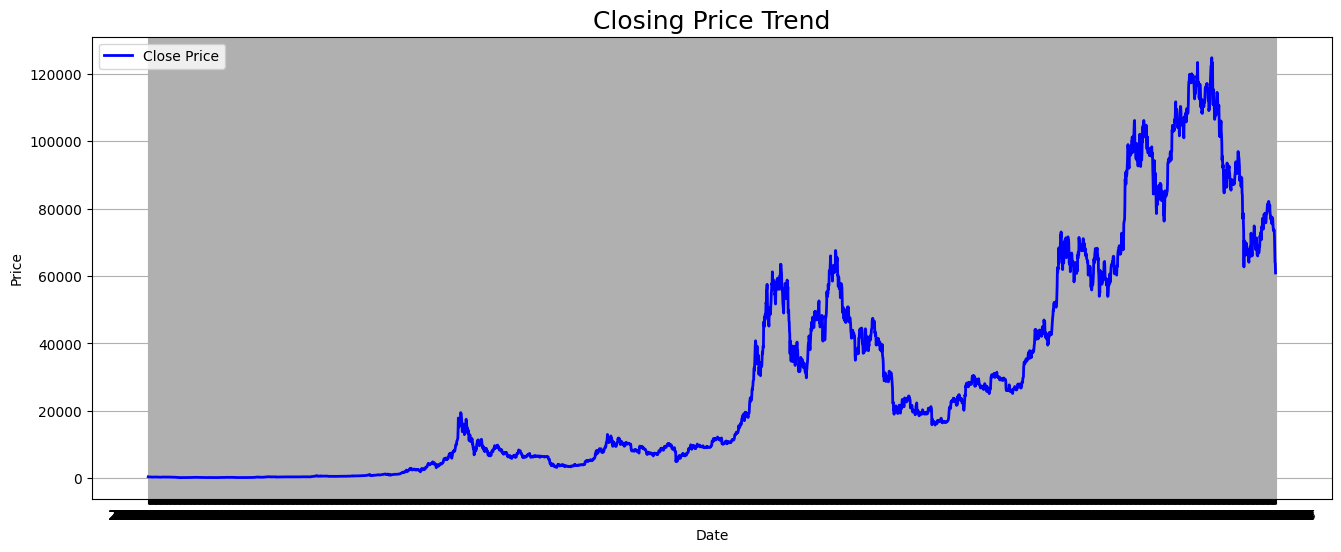

In [14]:
plt.figure(figsize=(16,6))
plt.plot(df['Date'], df['Close'],
         color='blue',
         linewidth=2,
         label='Close Price')
plt.title('Closing Price Trend', fontsize=18)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

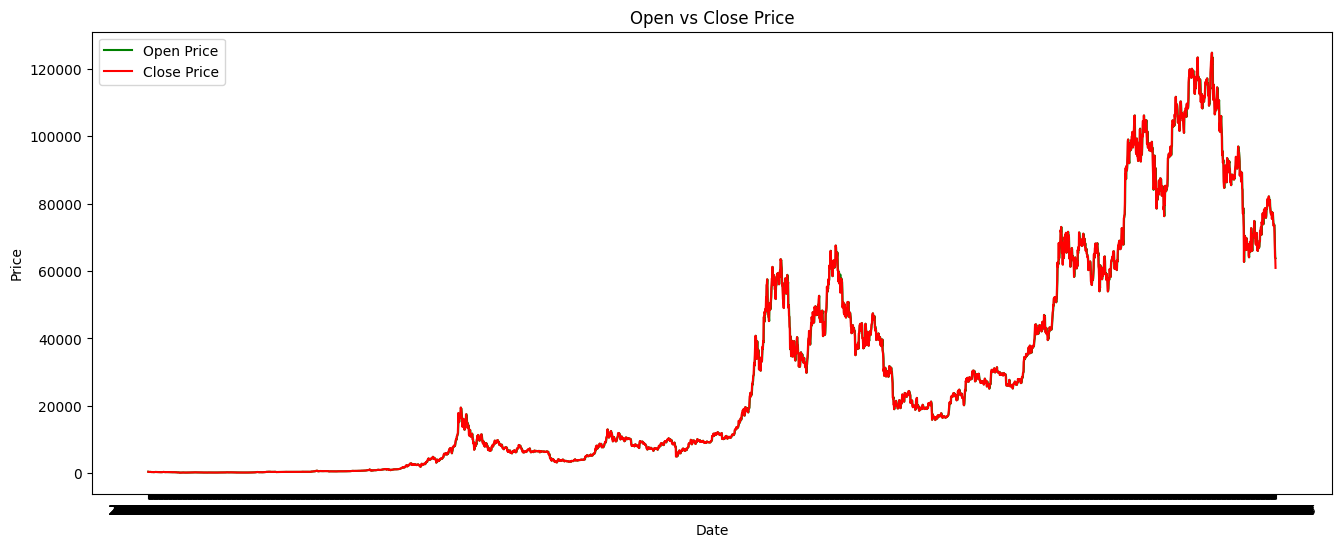

In [15]:
plt.figure(figsize=(16,6))
plt.plot(df['Date'], df['Open'],
         color='green',
         label='Open Price')

plt.plot(df['Date'], df['Close'],
         color='red',
         label='Close Price')

plt.title('Open vs Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

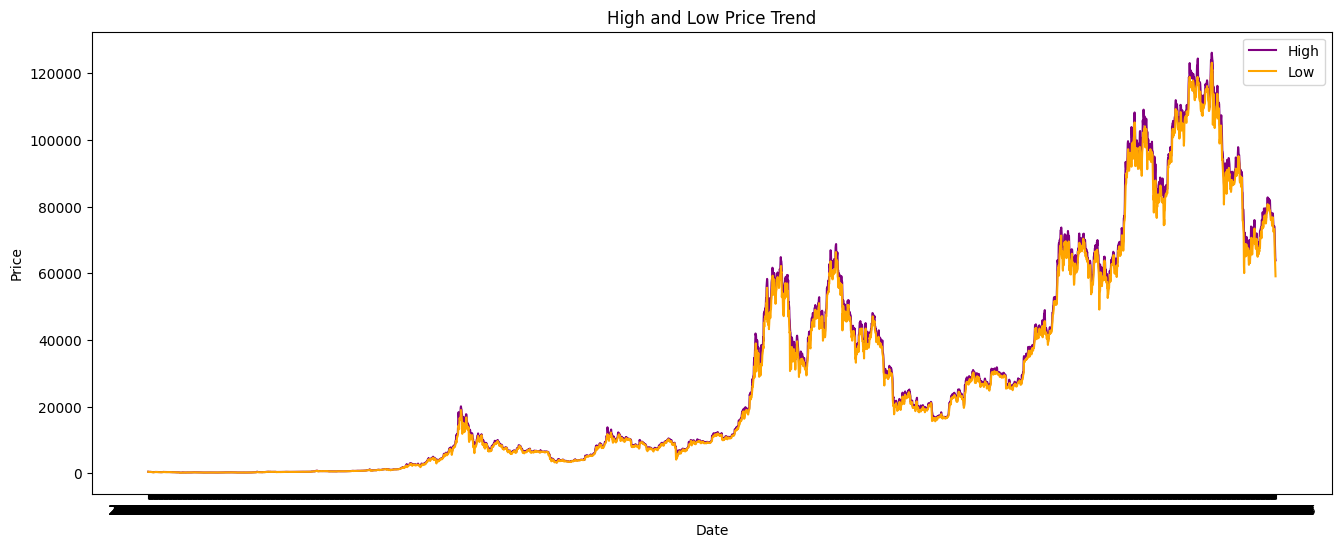

In [16]:
plt.figure(figsize=(16,6))

plt.plot(df['Date'], df['High'],
         color='purple',
         label='High')

plt.plot(df['Date'], df['Low'],
         color='orange',
         label='Low')

plt.title('High and Low Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


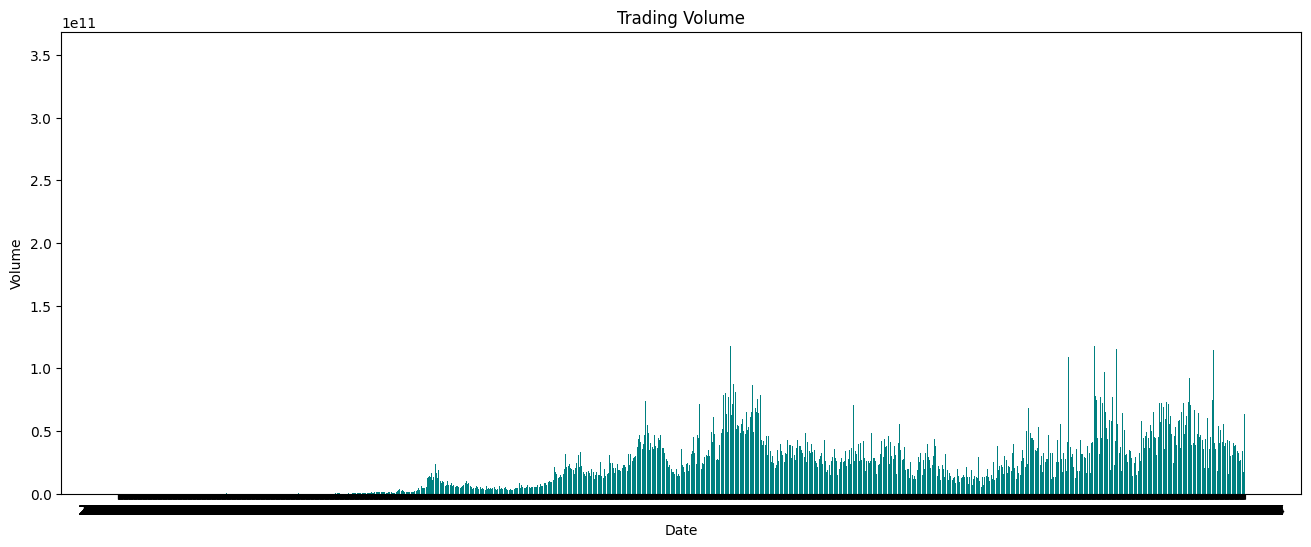

In [17]:
plt.figure(figsize=(16,6))

plt.bar(df['Date'],
        df['Volume'],
        color='teal')

plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

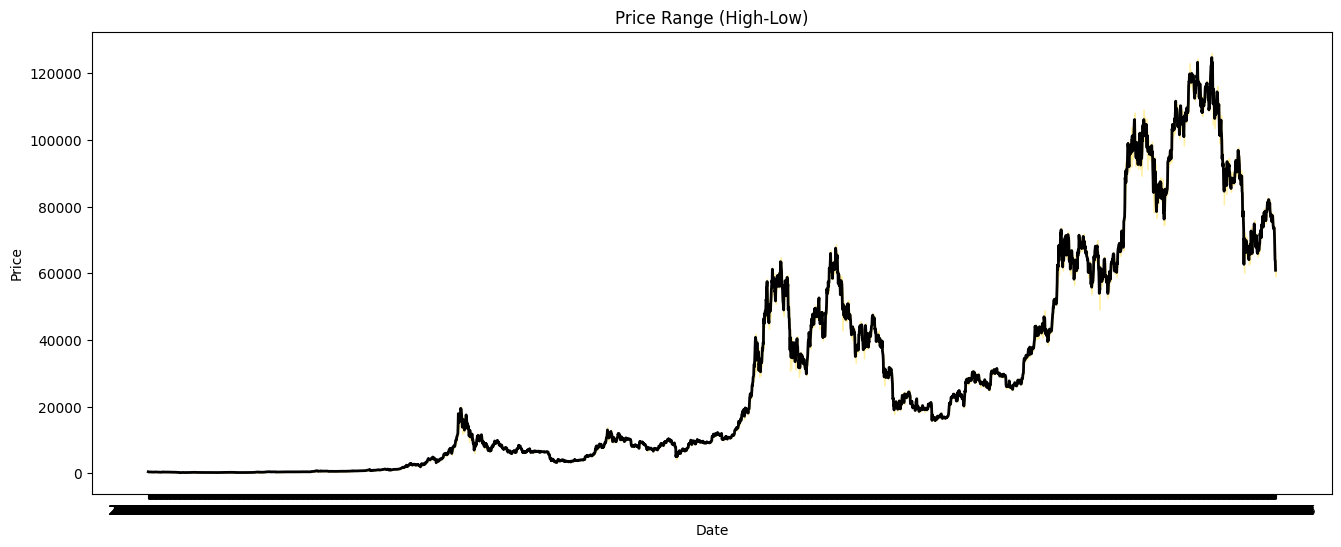

In [18]:
plt.figure(figsize=(16,6))

plt.fill_between(
    df['Date'],
    df['Low'],
    df['High'],
    alpha=0.3,
    color='gold'
)

plt.plot(df['Date'],
         df['Close'],
         color='black',
         linewidth=2)

plt.title('Price Range (High-Low)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()


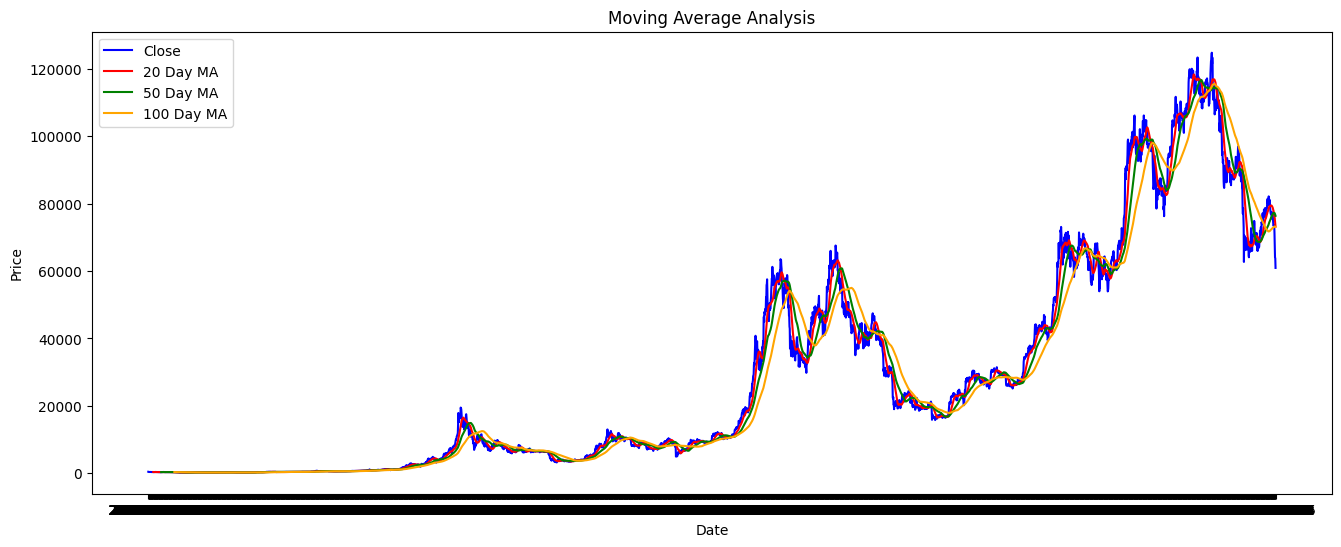

In [19]:
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['MA100'] = df['Close'].rolling(100).mean()

plt.figure(figsize=(16,6))

plt.plot(df['Date'], df['Close'],
         color='blue',
         label='Close')

plt.plot(df['Date'], df['MA20'],
         color='red',
         label='20 Day MA')

plt.plot(df['Date'], df['MA50'],
         color='green',
         label='50 Day MA')

plt.plot(df['Date'], df['MA100'],
         color='orange',
         label='100 Day MA')

plt.title('Moving Average Analysis')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


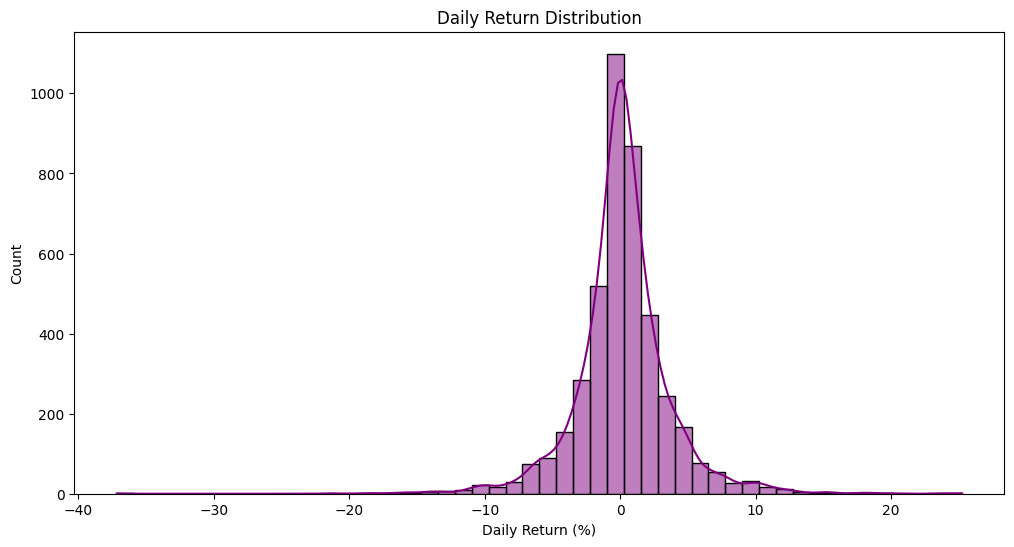

In [20]:
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(12,6))

sns.histplot(df['Daily_Return'],
             bins=50,
             kde=True,
             color='purple')

plt.title('Daily Return Distribution')
plt.xlabel('Daily Return (%)')
plt.show()

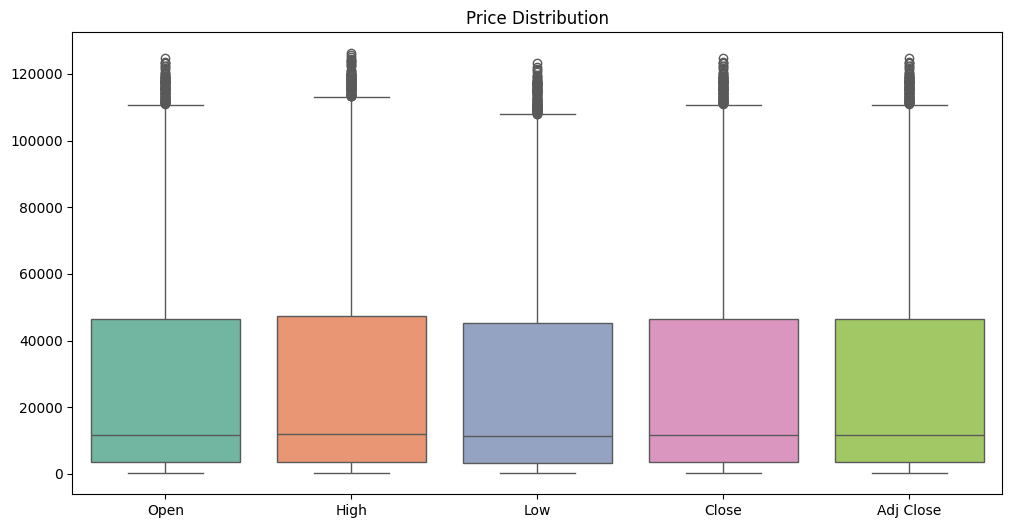

In [21]:
price_cols = ['Open','High','Low','Close','Adj Close']

plt.figure(figsize=(12,6))

sns.boxplot(data=df[price_cols],
            palette='Set2')

plt.title('Price Distribution')
plt.show()

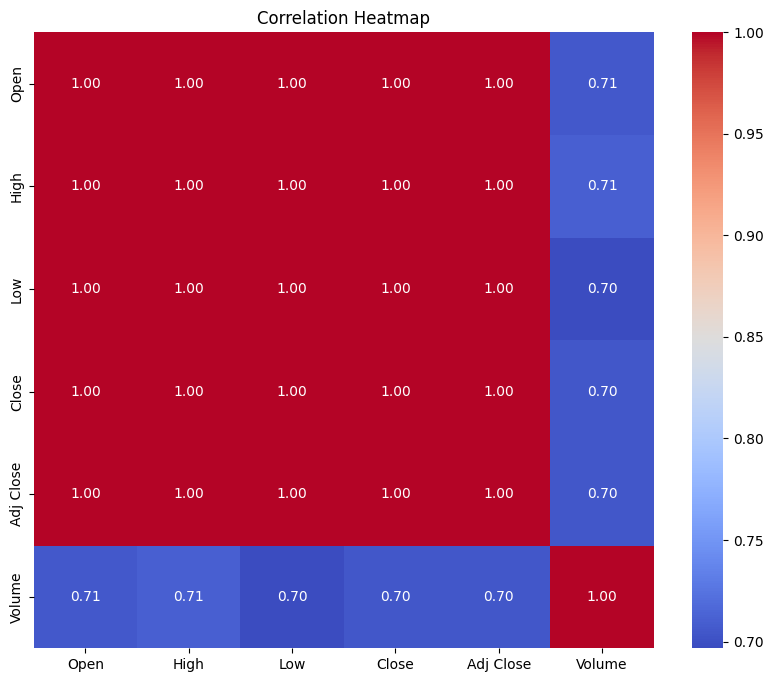

In [22]:
plt.figure(figsize=(10,8))

corr = df[['Open','High','Low',
           'Close','Adj Close',
           'Volume']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

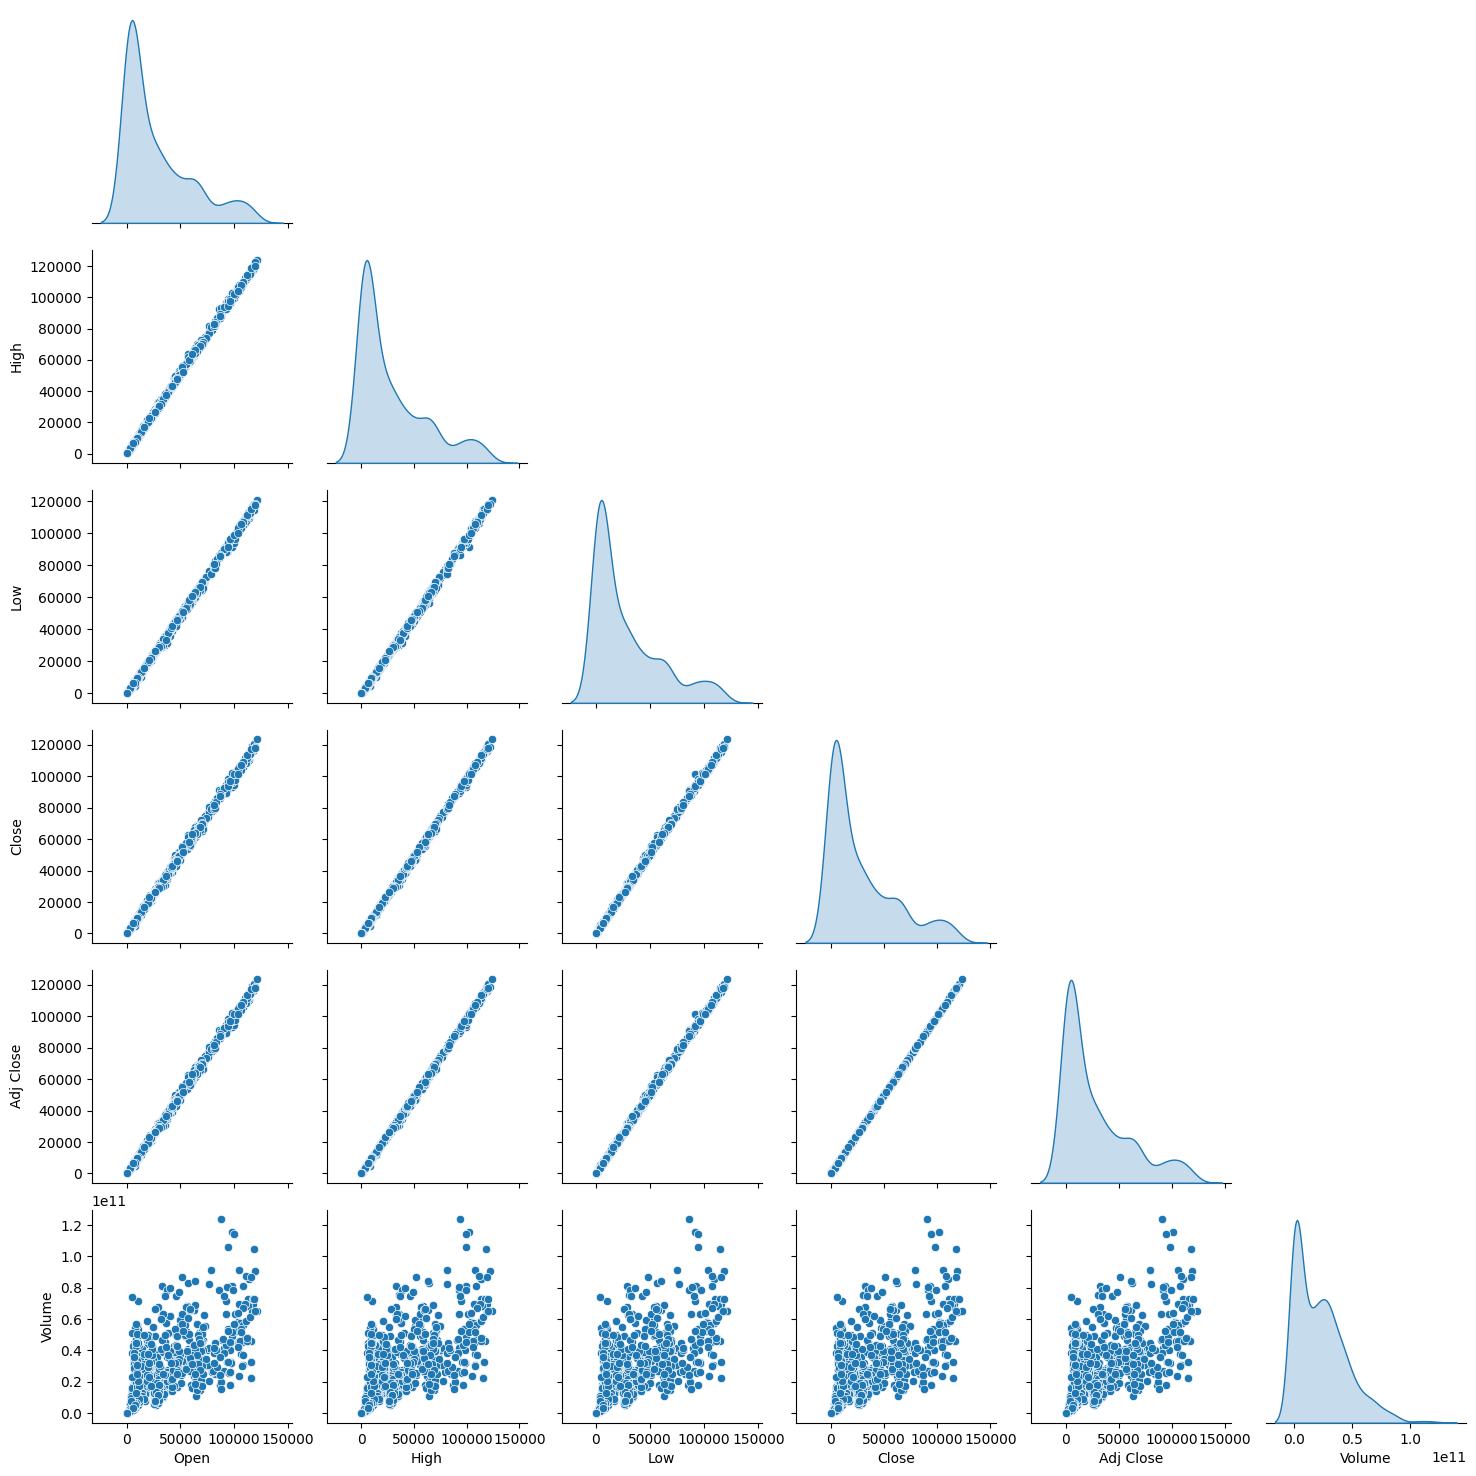

In [23]:
sns.pairplot(
    df[['Open','High','Low',
        'Close','Adj Close',
        'Volume']].sample(min(1000, len(df))),
    corner=True,
    diag_kind='kde'
)

plt.show()

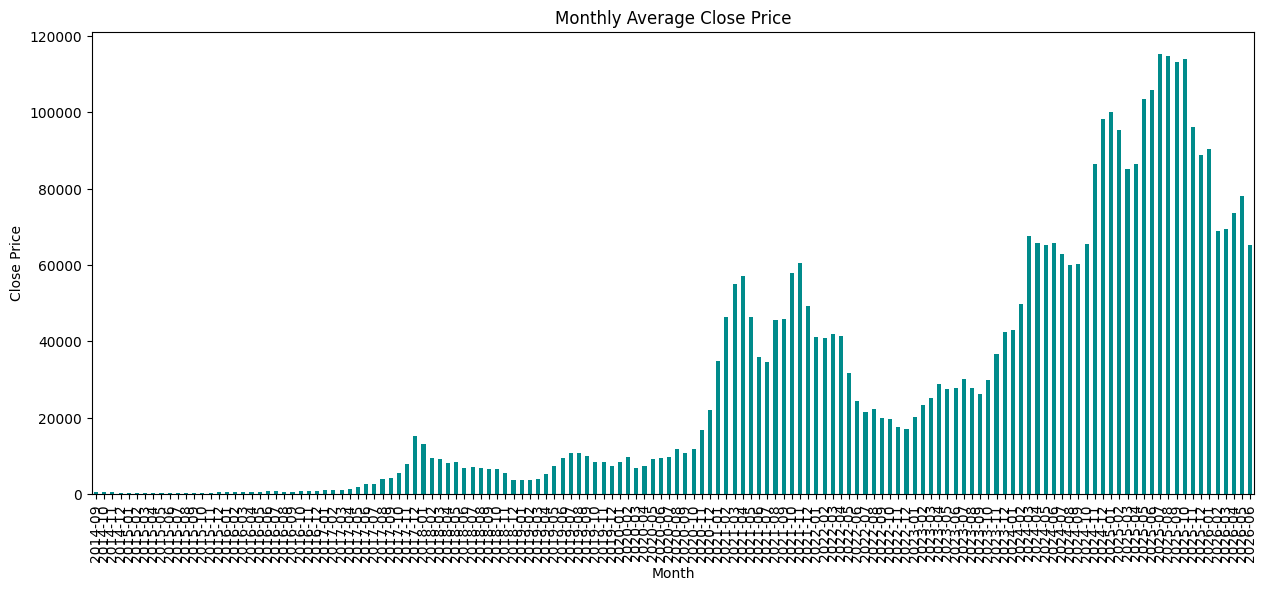

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df['Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(15,6))
monthly.plot(kind='bar', color='darkcyan')
plt.title('Monthly Average Close Price')
plt.ylabel('Close Price')
plt.show()

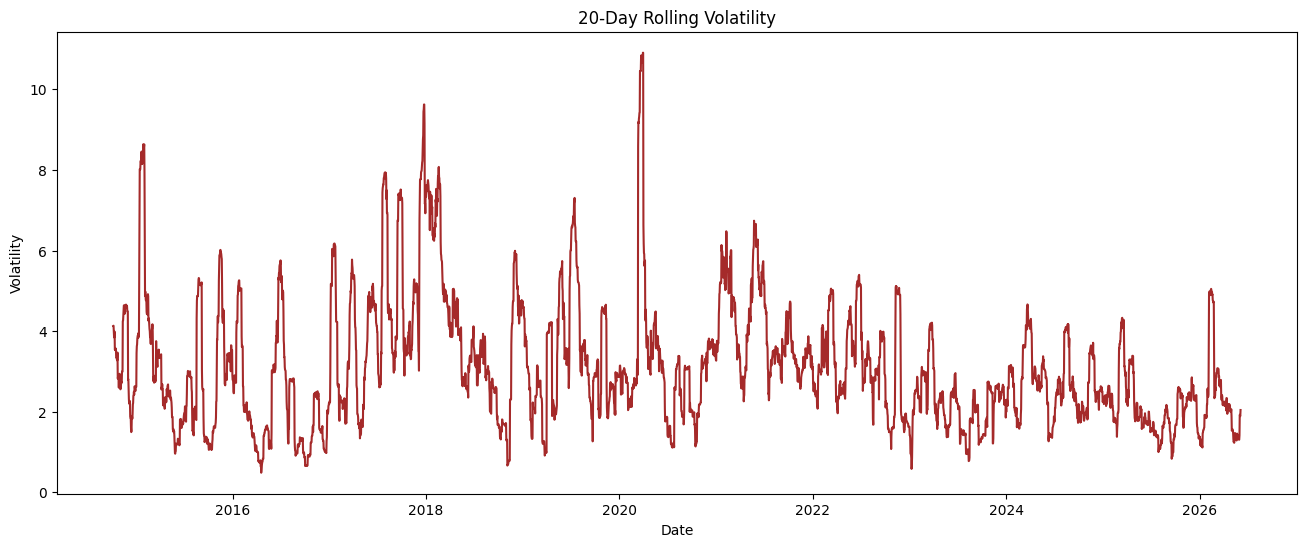

In [25]:
df['Volatility'] = df['Daily_Return'].rolling(20).std()

plt.figure(figsize=(16,6))

plt.plot(df['Date'],
         df['Volatility'],
         color='brown')

plt.title('20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()


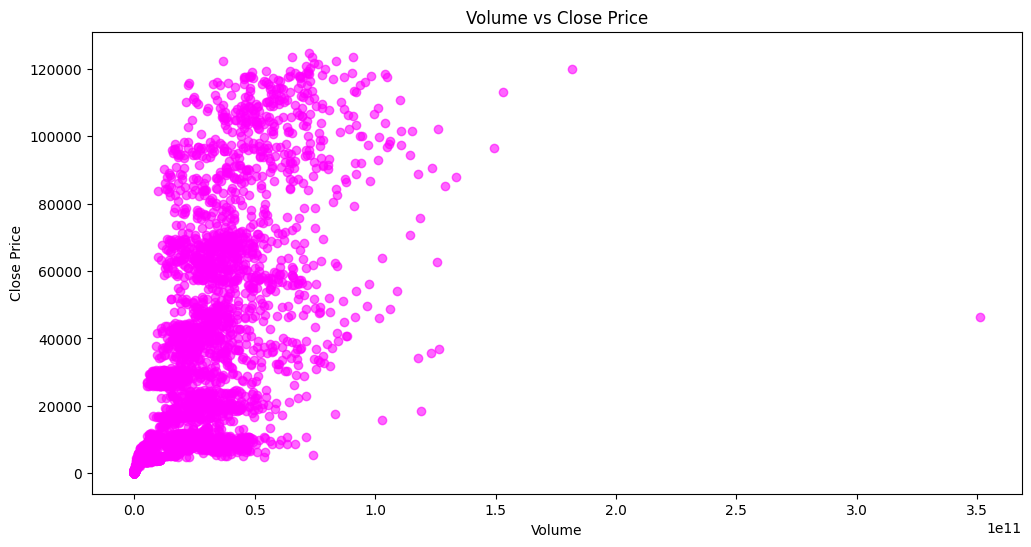

In [26]:
plt.figure(figsize=(12,6))

plt.scatter(df['Volume'],
            df['Close'],
            color='magenta',
            alpha=0.6)

plt.title('Volume vs Close Price')
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.show()

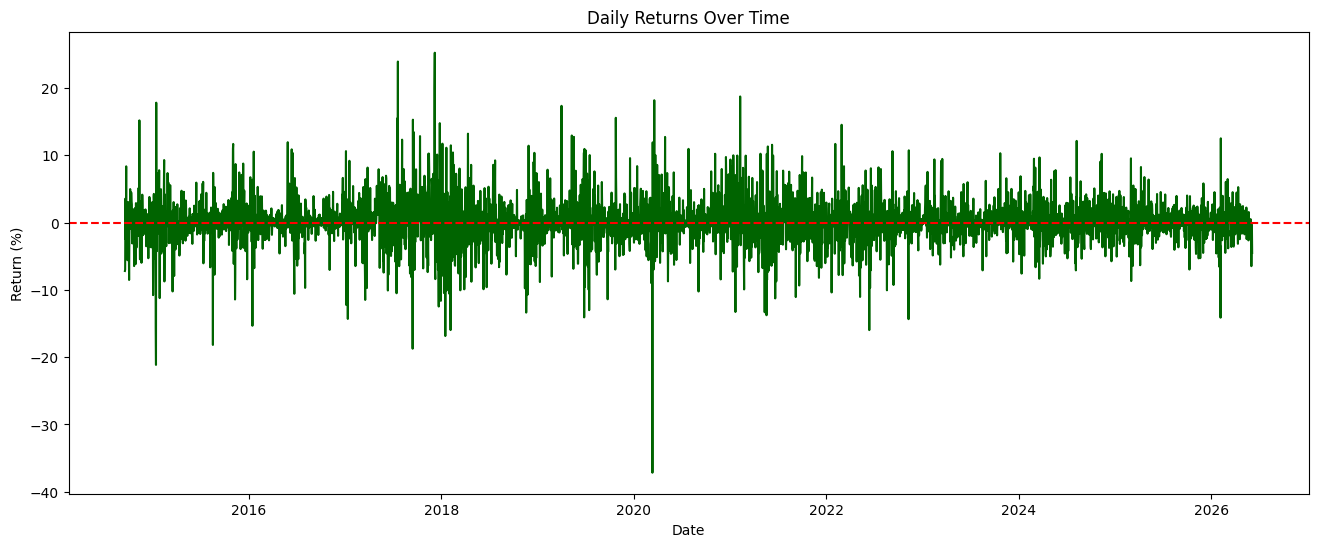

In [27]:
plt.figure(figsize=(16,6))

plt.plot(df['Date'],
         df['Daily_Return'],
         color='darkgreen')

plt.axhline(0,
            color='red',
            linestyle='--')

plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.show()

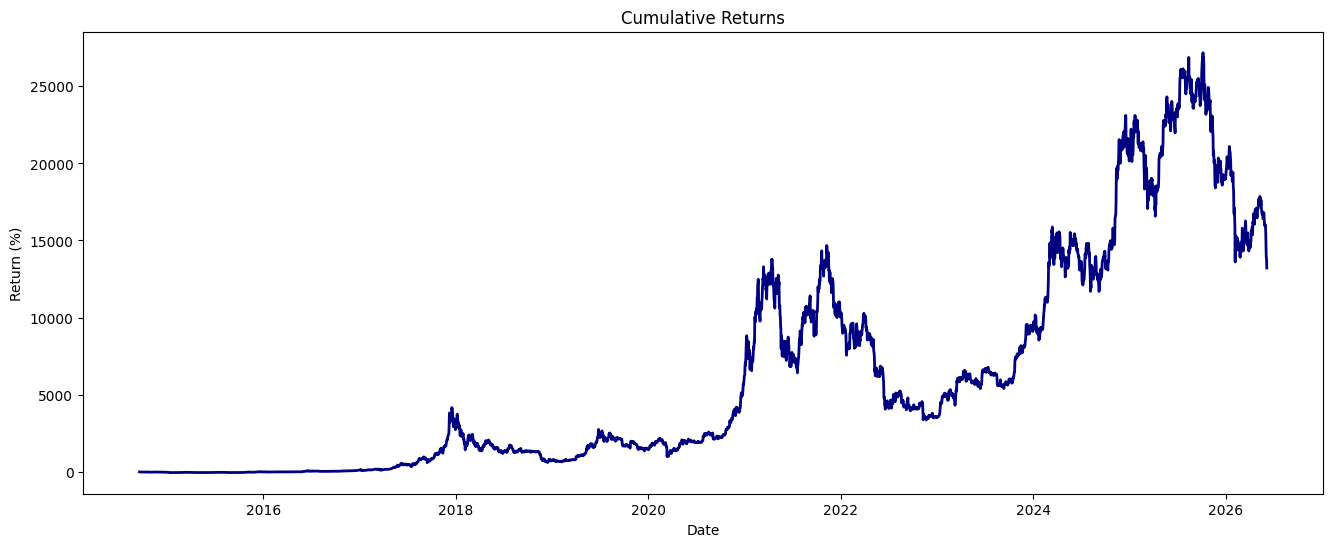

In [28]:
df['Cumulative_Return'] = (
    (1 + df['Daily_Return']/100).cumprod() - 1
) * 100

plt.figure(figsize=(16,6))

plt.plot(df['Date'],
         df['Cumulative_Return'],
         color='navy',
         linewidth=2)

plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.show()

In [29]:
print(df.describe())
print("\nMissing Values:\n")
print(df.isnull().sum())

                      Date           Open           High            Low  \
count                 4280    4280.000000    4280.000000    4280.000000   
mean   2020-07-26 12:00:00   28623.330630   29188.324150   28019.749124   
min    2014-09-17 00:00:00     176.897003     211.731003     171.509995   
25%    2017-08-21 18:00:00    3452.187439    3504.092224    3391.943420   
50%    2020-07-26 12:00:00   11536.727539   11850.328613   11288.414062   
75%    2023-07-01 06:00:00   46401.472656   47432.591797   45184.174805   
max    2026-06-05 00:00:00  124752.140625  126198.070312  123196.046875   
std                    NaN   32442.204251   32986.012544   31852.792883   

               Close      Adj Close        Volume           MA20  \
count    4280.000000    4280.000000  4.280000e+03    4261.000000   
mean    28636.451670   28636.451670  2.230348e+10   28605.957535   
min       178.102997     178.102997  5.914570e+06     226.383199   
25%      3458.813721    3458.813721  1.676575e+09   

## Feature engineering

Training Shape : (3344, 13)
Testing Shape  : (836, 13)


Logistic Regression

Accuracy : 0.5012
Precision: 0.5
Recall   : 0.0695
F1 Score : 0.1221
ROC AUC  : 0.5083

Confusion Matrix
[[390  29]
 [388  29]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.93      0.65       419
           1       0.50      0.07      0.12       417

    accuracy                           0.50       836
   macro avg       0.50      0.50      0.39       836
weighted avg       0.50      0.50      0.39       836



Random Forest

Accuracy : 0.5167
Precision: 0.597
Recall   : 0.0959
F1 Score : 0.1653
ROC AUC  : 0.5334

Confusion Matrix
[[392  27]
 [377  40]]

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.94      0.66       419
           1       0.60      0.10      0.17       417

    accuracy                           0.52       836
   macro avg       0.55      0.52      0.41       836
we

<Figure size 1000x800 with 0 Axes>

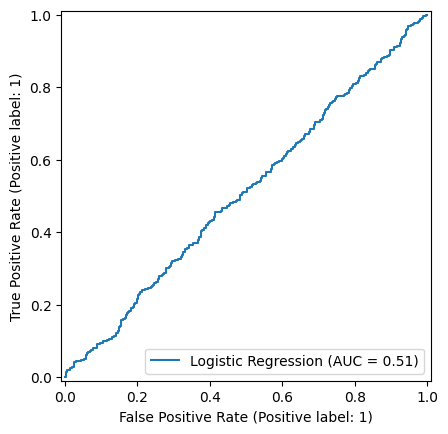

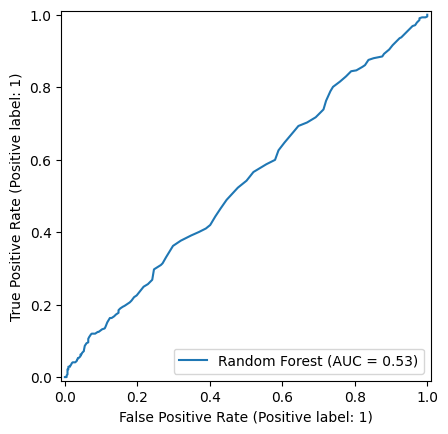

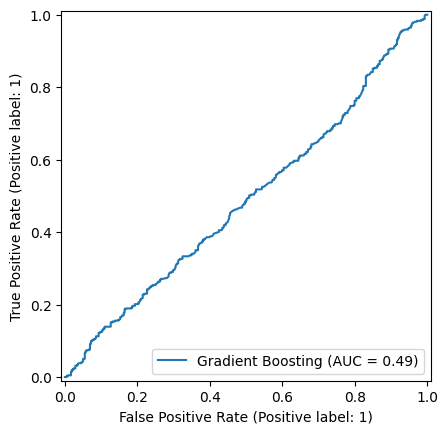

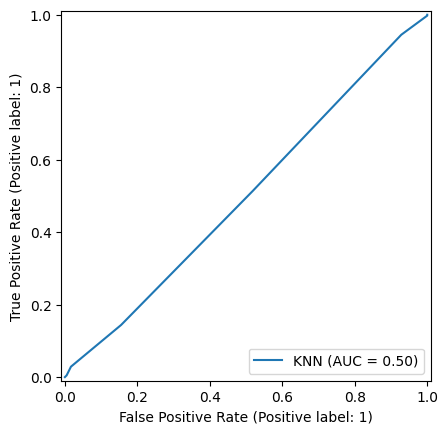

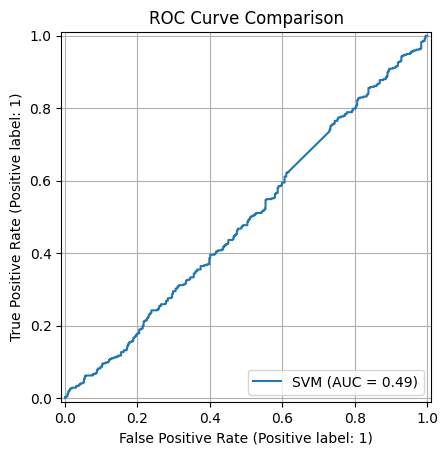

In [30]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)


df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')


# Tomorrow's close
df['Next_Close'] = df['Close'].shift(-1)

# Binary Target
df['Target'] = (df['Next_Close'] > df['Close']).astype(int)


df['Daily_Return'] = df['Close'].pct_change()

df['Price_Range'] = df['High'] - df['Low']

df['Open_Close_Diff'] = df['Close'] - df['Open']

df['MA5'] = df['Close'].rolling(5).mean()

df['MA10'] = df['Close'].rolling(10).mean()

df['MA20'] = df['Close'].rolling(20).mean()

df['Volatility'] = df['Daily_Return'].rolling(10).std()


df = df.dropna()


features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Adj Close',
    'Volume',
    'Daily_Return',
    'Price_Range',
    'Open_Close_Diff',
    'MA5',
    'MA10',
    'MA20',
    'Volatility'
]

X = df[features]

y = df['Target']


split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)



numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)


models = {
    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=7),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}


results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipe.fit(X_train, y_train)

    predictions = pipe.predict(X_test)

    probabilities = pipe.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc_auc = roc_auc_score(y_test, probabilities)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    print("\nAccuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc_auc,4))

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, predictions))

    print("\nClassification Report")

    print(classification_report(y_test, predictions))


results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

print("\n")
print(results_df.sort_values(
    by='ROC AUC',
    ascending=False
))


plt.figure(figsize=(10,8))

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipe.fit(X_train, y_train)

    RocCurveDisplay.from_estimator(
        pipe,
        X_test,
        y_test,
        name=name
    )

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!